# exp-gs-002-12 — event-token TF-IDF LR

환자별 변이 목록을 `G__`, `E__`, `TYPE__`, `AA__` token 문서로 변환한다. 매 outer fold에서 train 문서만으로 vocabulary와 IDF를 fit한다. 08 primary, TF-IDF 단독, 고정 확률 평균(0.5/0.5)을 3-seed OOF로 비교한다.

고정: `min_df=3`, `sublinear_tf=True`, unigram, LR `C=0.07`, `max_iter=2000`, `class_weight='balanced'`. 평가 데이터 파일은 OOF에서 읽지 않는다.


In [1]:
from pathlib import Path
import subprocess, sys, json
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

def find_eda_dir():
    for path in (Path.cwd(), *Path.cwd().parents):
        direct=path/'common'/'exp-gs-002-memory-safe.py'
        project=path/'experiments'/'gs'/'notebooks'/'eda_pre_002'/'common'/'exp-gs-002-memory-safe.py'
        if direct.exists(): return path
        if project.exists(): return project.parent.parent
    raise FileNotFoundError('eda_pre_002 실행기를 찾지 못했습니다.')

EDA_DIR=find_eda_dir(); RUNNER=EDA_DIR/'common'/'exp-gs-002-memory-safe.py'; RESULT_DIR=EDA_DIR/'result'; RESULT_DIR.mkdir(exist_ok=True)
RUN_ID='exp-gs-002-12'; CANDIDATE='H-AS-LR-exact-confusion-pairs-Apair-log1p'; SEEDS=(42,2024,777); MIN_DF=3; RUN_EXPERIMENT=True; OOF_TRAIN_ONLY=True
print({'runner':RUNNER,'seeds':SEEDS,'min_df':MIN_DF,'oof_train_only':OOF_TRAIN_ONLY})


{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/eda_pre_002/common/exp-gs-002-memory-safe.py'), 'seeds': (42, 2024, 777), 'min_df': 3, 'oof_train_only': True}


/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if RUN_EXPERIMENT:
    for seed in tqdm(SEEDS, desc='12 | event-token TF-IDF | OOF', unit='seed'):
        subprocess.run([sys.executable,str(RUNNER),'--run-id',RUN_ID,'--candidate',CANDIDATE,'--seed',str(seed),'--event-tfidf','--tfidf-min-df',str(MIN_DF)],check=True)
else:
    print('RUN_EXPERIMENT=False: 결과 집계만 수행합니다.')


row-local mutation cache: 100%|██████████| 4384/4384 [00:10<00:00, 400.94it/s]
H-AS-LR-exact-confusion-pairs-Apair-log1p | event-tfidf | seed 42: 100%|██████████| 5/5 [03:24<00:00, 40.88s/it]


{
  "experiment_id": "H-AS-LR-exact-confusion-pairs-Apair-log1p",
  "model": "logistic",
  "seed": 42,
  "tfidf_min_df": 3,
  "tfidf_sublinear_tf": true,
  "primary_oof_macro_f1": 0.47814168846488037,
  "event_tfidf_oof_macro_f1": 0.3782884640237529,
  "blend_0p5_oof_macro_f1": 0.4794557135599829,
  "delta_blend_vs_primary": 0.0013140250951025334,
  "primary_oof_accuracy": 0.45879696823093047,
  "event_tfidf_oof_accuracy": 0.3971940009675859,
  "blend_0p5_oof_accuracy": 0.45992581841638447,
  "feature_count_mean": 8175.2,
  "tfidf_vocabulary_size_mean": 5875.8,
  "runtime_seconds": 204.58974695899815,
  "primary_convergence_warning_count": 0,
  "tfidf_convergence_warning_count": 0,
  "convergence_warning_count": 0,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


row-local mutation cache: 100%|██████████| 4384/4384 [00:10<00:00, 401.62it/s]]
H-AS-LR-exact-confusion-pairs-Apair-log1p | event-tfidf | seed 2024: 100%|██████████| 5/5 [03:20<00:00, 40.04s/it]


{
  "experiment_id": "H-AS-LR-exact-confusion-pairs-Apair-log1p",
  "model": "logistic",
  "seed": 2024,
  "tfidf_min_df": 3,
  "tfidf_sublinear_tf": true,
  "primary_oof_macro_f1": 0.4762175133106753,
  "event_tfidf_oof_macro_f1": 0.37834570023612246,
  "blend_0p5_oof_macro_f1": 0.4770919206532897,
  "delta_blend_vs_primary": 0.0008744073426144028,
  "primary_oof_accuracy": 0.4594420254797613,
  "event_tfidf_oof_accuracy": 0.397677793904209,
  "blend_0p5_oof_accuracy": 0.4591194968553459,
  "feature_count_mean": 8175.0,
  "tfidf_vocabulary_size_mean": 5868.4,
  "runtime_seconds": 200.37739150000561,
  "primary_convergence_warning_count": 0,
  "tfidf_convergence_warning_count": 0,
  "convergence_warning_count": 0,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 392.53it/s]]
H-AS-LR-exact-confusion-pairs-Apair-log1p | event-tfidf | seed 777: 100%|██████████| 5/5 [03:10<00:00, 38.15s/it]


{
  "experiment_id": "H-AS-LR-exact-confusion-pairs-Apair-log1p",
  "model": "logistic",
  "seed": 777,
  "tfidf_min_df": 3,
  "tfidf_sublinear_tf": true,
  "primary_oof_macro_f1": 0.481145738774279,
  "event_tfidf_oof_macro_f1": 0.3705716160280971,
  "blend_0p5_oof_macro_f1": 0.48436600336351787,
  "delta_blend_vs_primary": 0.0032202645892388526,
  "primary_oof_accuracy": 0.4613771972262538,
  "event_tfidf_oof_accuracy": 0.39138848572810836,
  "blend_0p5_oof_accuracy": 0.46411869053378485,
  "feature_count_mean": 8170.4,
  "tfidf_vocabulary_size_mean": 5869.6,
  "runtime_seconds": 190.9427847499901,
  "primary_convergence_warning_count": 0,
  "tfidf_convergence_warning_count": 0,
  "convergence_warning_count": 0,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


12 | event-token TF-IDF | OOF: 100%|██████████| 3/3 [11:08<00:00, 222.71s/seed]


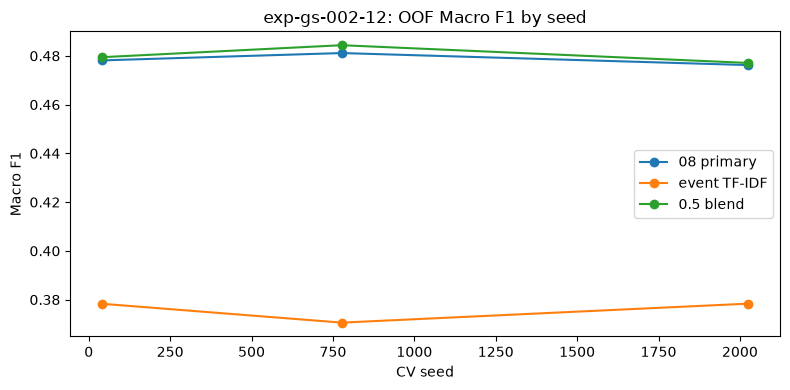

,experiment_id,model,seed,tfidf_min_df,tfidf_sublinear_tf,primary_oof_macro_f1,event_tfidf_oof_macro_f1,blend_0p5_oof_macro_f1,delta_blend_vs_primary,primary_oof_accuracy,event_tfidf_oof_accuracy,blend_0p5_oof_accuracy,feature_count_mean,tfidf_vocabulary_size_mean,runtime_seconds,primary_convergence_warning_count,tfidf_convergence_warning_count,convergence_warning_count,leakage_check,nan_as_mutation_count
0,H-AS-LR-exact-confusion-pairs-Apair-log1p,logistic,42,3,True,0.478142,0.378288,0.479456,0.001314,0.458797,0.397194,0.459926,8175.2,5875.8,204.589747,0,0,0,True,0
2,H-AS-LR-exact-confusion-pairs-Apair-log1p,logistic,777,3,True,0.481146,0.370572,0.484366,0.003220,0.461377,0.391388,0.464119,8170.4,5869.6,190.942785,0,0,0,True,0
1,H-AS-LR-exact-confusion-pairs-Apair-log1p,logistic,2024,3,True,0.476218,0.378346,0.477092,0.000874,0.459442,0.397678,0.459119,8175.0,5868.4,200.377392,0,0,0,True,0


,experiment_id,seed_count,min_df,primary_macro_f1_mean,event_tfidf_macro_f1_mean,blend_0p5_macro_f1_mean,blend_delta_mean,blend_delta_std,all_seed_blend_delta_positive,tfidf_vocab_size_mean,feature_count_mean,convergence_warning_count,leakage_check,nan_as_mutation_count
0,exp-gs-002-12,3,3,0.478502,0.375735,0.480305,0.001803,0.001247,True,5871.266667,8173.533333,0,True,0


In [3]:
def path(seed,suffix): return RESULT_DIR/f'{RUN_ID}_{CANDIDATE}_event-tfidf_seed{seed}_{suffix}.csv'
files=[path(seed,'oof') for seed in SEEDS]
missing=[p for p in files if not p.exists()]
if missing: raise FileNotFoundError('누락 결과:\n'+'\n'.join(map(str,missing)))
per_seed=pd.concat([pd.read_csv(p) for p in files],ignore_index=True).sort_values('seed')
assert per_seed['leakage_check'].all() and per_seed['nan_as_mutation_count'].eq(0).all() and per_seed['tfidf_min_df'].eq(MIN_DF).all()
summary=pd.DataFrame([{
 'experiment_id':RUN_ID,'seed_count':len(SEEDS),'min_df':MIN_DF,
 'primary_macro_f1_mean':per_seed.primary_oof_macro_f1.mean(),'event_tfidf_macro_f1_mean':per_seed.event_tfidf_oof_macro_f1.mean(),'blend_0p5_macro_f1_mean':per_seed.blend_0p5_oof_macro_f1.mean(),
 'blend_delta_mean':per_seed.delta_blend_vs_primary.mean(),'blend_delta_std':per_seed.delta_blend_vs_primary.std(),'all_seed_blend_delta_positive':bool(per_seed.delta_blend_vs_primary.gt(0).all()),
 'tfidf_vocab_size_mean':per_seed.tfidf_vocabulary_size_mean.mean(),'feature_count_mean':per_seed.feature_count_mean.mean(),'convergence_warning_count':per_seed.convergence_warning_count.sum(),
 'leakage_check':bool(per_seed.leakage_check.all()),'nan_as_mutation_count':int(per_seed.nan_as_mutation_count.sum())
}])
class_seed=pd.concat([pd.read_csv(path(seed,'class_f1')).assign(seed=seed) for seed in SEEDS],ignore_index=True)
class_summary=class_seed.groupby(['variant','class'],as_index=False).agg(class_f1_mean=('f1-score','mean'),class_f1_std=('f1-score','std'),support=('support','first'))
per_seed.to_csv(RESULT_DIR/'exp-gs-002-12_per_seed.csv',index=False); summary.to_csv(RESULT_DIR/'exp-gs-002-12_summary.csv',index=False); class_summary.to_csv(RESULT_DIR/'exp-gs-002-12_class_f1_summary.csv',index=False)
fig,ax=plt.subplots(figsize=(8,4))
for col,label in [('primary_oof_macro_f1','08 primary'),('event_tfidf_oof_macro_f1','event TF-IDF'),('blend_0p5_oof_macro_f1','0.5 blend')]: ax.plot(per_seed.seed,per_seed[col],marker='o',label=label)
ax.set(title='exp-gs-002-12: OOF Macro F1 by seed',xlabel='CV seed',ylabel='Macro F1'); ax.legend(); fig.tight_layout(); fig.savefig(RESULT_DIR/'exp-gs-002-12_oof_macro_f1.png',dpi=160,bbox_inches='tight'); plt.show()
display(per_seed); display(summary)
